
## Análisis de rendimiento estudiantil

Análisis exploratorio del dataset "Students Performance in Exams" 
(Kaggle), para entender qué factores se relacionan con las notas 
de los estudiantes en matemáticas, lectura y escritura.

## Cargar los datos

Cargo el dataset y reviso las primeras filas para confirmar que se leyó correctamente.


In [48]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('StudentsPerformance.csv')
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


## Información general del dataset

Reviso cuántas filas y columnas hay, y qué tipo de dato tiene cada una.

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## Revisión de valores nulos

1. Verifico si hay datos faltantes en alguna columna antes de continuar con el análisis.

2. No se encontraron valores nulos en ninguna columna — el dataset está 
completo y no requiere limpieza adicional en este aspecto.

In [26]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Estadísticas descriptivas

Reviso promedio, mínimo, máximo y otros valores clave de las notas 
para tener una primera idea general antes de profundizar.

In [ ]:

df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## ¿El curso de preparación para el examen? ¿Mejora las calificaciones?


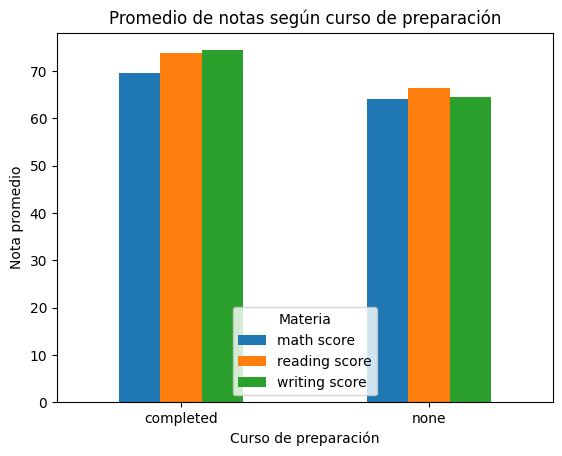

In [ ]:


df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()


df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean().plot(kind='bar')
plt.title('Promedio de notas según curso de preparación')
plt.ylabel('Nota promedio')
plt.xlabel('Curso de preparación')
plt.xticks(rotation=0)
plt.legend(title='Materia')
plt.show()

Los estudiantes que completaron el curso de preparación sacaron 
mejores notas en las 3 materias. La diferencia más grande se ve 
en escritura (+9.9 puntos) y la más chica en matemáticas (+5.6 puntos).

## ¿Hay diferencia de calificaciones por genero?

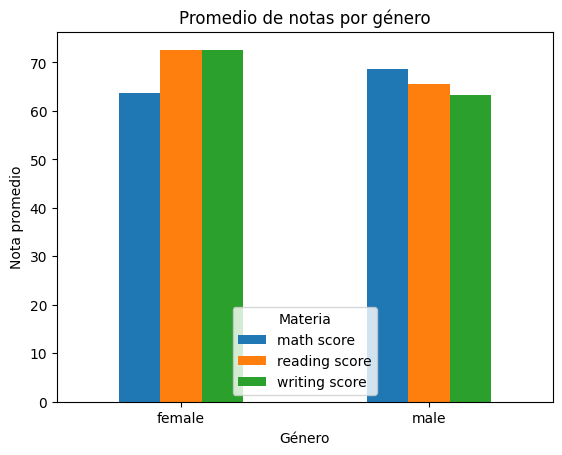

In [ ]:


df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().plot(kind='bar')
plt.title('Promedio de notas por género')
plt.ylabel('Nota promedio')
plt.xlabel('Género')
plt.xticks(rotation=0)
plt.legend(title='Materia')
plt.show()

Las mujeres obtienen mejores notas en lectura y escritura, mientras 
que los hombres obtienen una nota ligeramente más alta en matemáticas. 
Esto sugiere una diferencia de rendimiento según la materia más que 
una ventaja general de un género sobre el otro.

## ¿Cómo se distribuyen las notas de matemáticas?

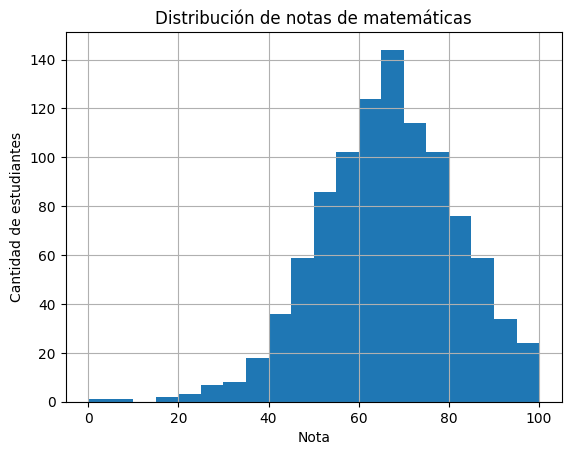

In [ ]:

df['math score'].hist(bins=20)
plt.title('Distribución de notas de matemáticas')
plt.xlabel('Nota')
plt.ylabel('Cantidad de estudiantes')
plt.show()

La mayor cantidad de estudiantes se concentra alrededor de 70 puntos 
en matemáticas, formando una distribución en forma de campana: pocos 
estudiantes sacan notas muy bajas o muy altas, y la mayoría se agrupa 
cerca del promedio.

 ## ¿El nivel educativo de los padres influye en las notas?


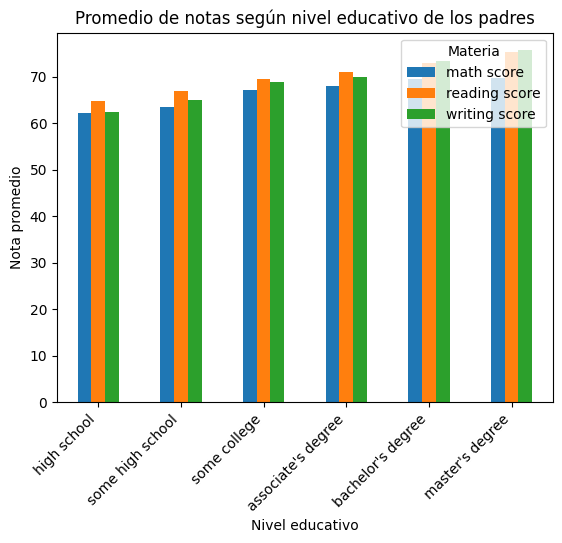

In [ ]:

df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()
df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean().sort_values('math score').plot(kind='bar')
plt.title('Promedio de notas según nivel educativo de los padres')
plt.ylabel('Nota promedio')
plt.xlabel('Nivel educativo')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Materia')
plt.show()

Los estudiantes cuyos padres tienen mayor nivel educativo (master's, 
bachelor's) tienden a sacar mejores notas que los que solo llegaron 
a high school — la diferencia llega a 13 puntos en escritura. 
Esto es una correlación, no significa que uno cause el otro.

## Promedio de notas por grupo (A, B, C, D, E)

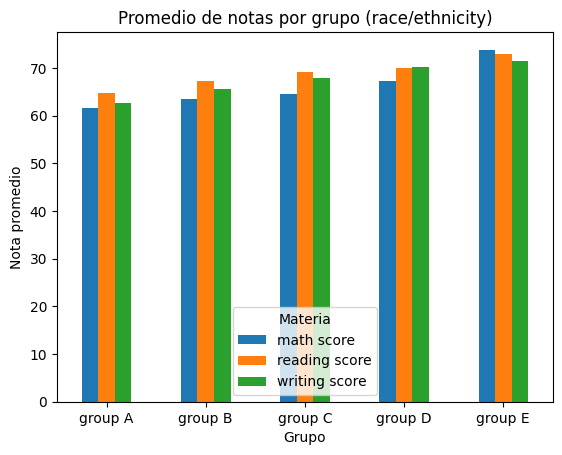

In [ ]:

df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean()

df.groupby('race/ethnicity')[['math score', 'reading score', 'writing score']].mean().plot(kind='bar')
plt.title('Promedio de notas por grupo (race/ethnicity)')
plt.ylabel('Nota promedio')
plt.xlabel('Grupo')
plt.xticks(rotation=0)
plt.legend(title='Materia')
plt.show()

El Group E tiene las notas promedio más altas, y el Group A las más bajas.

## ¿Cuántos estudiantes hay en cada grupo?

In [ ]:


df['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64


## ¿El curso de preparación ayuda igual en todos los grupos, o más en unos que en otros?

In [ ]:

df.groupby(['race/ethnicity', 'test preparation course'])[['math score','reading score', 'writing score']].mean()

math score  reading score  \
race/ethnicity test preparation course                              
group A        completed                 68.258065      71.032258   
               none                      58.086207      61.275862   
group B        completed                 67.191176      72.852941   
               none                      61.368852      64.286885   
group C        completed                 67.495726      73.658120   
               none                      62.707921      66.465347   
group D        completed                 69.792683      74.146341   
               none                      66.255556      68.155556   
group E        completed                 77.433333      76.666667   
               none                      71.112500      70.300000   

                                        writing score  
race/ethnicity test preparation course                 
group A        completed                    70.903226  
               none                         58.275862  
group B        completed                    71.882353  
               none                         62.098361  
group C        completed                    74.452991  
               none                         63.990099  
group D        completed                    76.658537  
               none                         67.177778  
group E        completed                    75.983333  
               none                         67.975000

El curso ayuda en los 5 grupos, pero el impacto es mayor en el Group A 
(+10.2 puntos en matemáticas) que en el Group D (+3.5 puntos). Esto 
sugiere que el curso podría ayudar más a quienes parten de notas más bajas.

## ¿El nivel educativo de los padres varía según el grupo?


In [ ]:

df.groupby('race/ethnicity')['parental level of education'].value_counts()

race/ethnicity  parental level of education
group A         some high school               24
                high school                    18
                some college                   18
                associate's degree             14
                bachelor's degree              12
                master's degree                 3
group B         high school                    48
                associate's degree             41
                some high school               38
                some college                   37
                bachelor's degree              20
                master's degree                 6
group C         associate's degree             78
                some college                   69
                high school                    64
                some high school               49
                bachelor's degree              40
                master's degree                19
group D         some college                   67
      

Reviso si ciertos grupos étnicos tienen más concentración de padres 
con determinado nivel educativo, para entender si esto podría explicar 
parte de las diferencias de notas vistas antes.

Se observa que la composición de nivel educativo de los padres varía 
por grupo: el Group A tiene mayor concentración en niveles educativos 
más bajos (solo 3 padres con master's degree), mientras que grupos 
como C y D tienen una distribución más repartida entre niveles medios 
y altos. Esto podría ayudar a explicar por qué el Group A mostró las 
notas promedio más bajas.

## Promedio general por estudiante

Creo una columna con el promedio de las 3 materias para poder comparar 
el rendimiento general de cada estudiante de forma más simple.

In [56]:
df['promedio'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

## Correlación entre materias

Reviso si los estudiantes que sacan buena nota en una materia tienden 
a sacar buena nota también en las otras.

In [49]:
df[['math score', 'reading score', 'writing score']].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


## Los 10 estudiantes con mejor promedio

In [ ]:
df.sort_values('promedio', ascending=False).head(10)  

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,promedio
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
712,female,group D,some college,standard,none,98,100,99,99.000000
179,female,group D,some high school,standard,completed,97,100,100,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,97.666667


## Los 10 estudiantes con menor promedio

In [ ]:
df.sort_values('promedio', ascending=True).head(10)  

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,promedio
59,female,group C,some high school,free/reduced,none,0,17,10,9.000000
980,female,group B,high school,free/reduced,none,8,24,23,18.333333
596,male,group B,high school,free/reduced,none,30,24,15,23.000000
327,male,group A,some college,free/reduced,none,28,23,19,23.333333
17,female,group B,some high school,free/reduced,none,18,32,28,26.000000
76,male,group E,some high school,standard,none,30,26,22,26.000000
601,female,group C,high school,standard,none,29,29,30,29.333333
338,female,group B,some high school,free/reduced,none,24,38,27,29.666667
787,female,group B,some college,standard,none,19,38,32,29.666667
211,male,group C,some college,free/reduced,none,35,28,27,30.000000


## Guardar resultados

Exporto el dataset con la columna de promedio incluida, para dejar 
un archivo final con el análisis completo.

In [55]:
df.to_csv('students_analisis_final.csv', index=False)

## Conclusiones generales

- El curso de preparación mejora las notas en todas las materias y en todos los grupos.
- El nivel educativo de los padres está relacionado con mejores notas.
- El Group E tiene el mejor desempeño promedio; el Group A el más bajo.
- El impacto del curso de preparación es mayor en estudiantes que parten de notas más bajas.
- Estos resultados son correlaciones observadas en los datos, no relaciones de causa-efecto comprobadas.